In [30]:
import os
CUDA_VISIBLE_DEVICES=0
os.environ['CUDA_VISIBLE_DEVICES'] = f"{CUDA_VISIBLE_DEVICES}"
import torch
print(f"visible GPUs: {torch.cuda.device_count()}")
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

visible GPUs: 1


# Sanity Check

The new generative frontiers analysis requiere entropies to be good estimates. We begin the analysis by comparing both.

$$
{\mathrm{KL}}(q_{\text{gen}} \,\|\, p_{\text{ref}}) = H(q_{\text{gen}}, p_{\text{ref}}) - H(q_{\text{gen}})
$$ 

If we use $p_{ref}$ and $q_{gen}$ from the same model we get $ H(q_{\text{gen}}) $

## Loading Results

In [31]:
GPT2_REAL_ENTROPY_PATH = "outputs/gpt2_real_entropy/openai-community_gpt2/metrics.csv"
GPT2_MEDIUM_REAL_ENTROPY_PATH = "outputs/gpt2medium_real_entropy/openai-community_gpt2-medium/metrics.csv"
GPT2_LARGE_REAL_ENTROPY_PATH = "outputs/gpt2large_real_entropy/openai-community_gpt2-large/metrics.csv"
GPT2_XL_REAL_ENTROPY_PATH = "outputs/gpt2xl_real_entropy/openai-community_gpt2-xl/metrics.csv"

GPT2_EST_ENTROPY_PATH = "outputs/qwen4B_gen_frontiers/openai-community_gpt2/metrics.csv"
GPT2_MEDIUM_EST_ENTROPY_PATH = "outputs/qwen4B_gen_frontiers/openai-community_gpt2-medium/metrics.csv"
GPT2_LARGE_EST_ENTROPY_PATH = "outputs/qwen4B_gen_frontiers/openai-community_gpt2-large/metrics.csv"
GPT2_XL_EST_ENTROPY_PATH = "outputs/qwen4B_gen_frontiers/openai-community_gpt2-xl/metrics.csv"

PARAM_FREE_PATH = "outputs/parameter_free_gen_frontiers/metrics.csv"

df_gpt2_real_entropy = pd.read_csv(GPT2_REAL_ENTROPY_PATH)
df_gpt2_medium_real_entropy = pd.read_csv(GPT2_MEDIUM_REAL_ENTROPY_PATH)
df_gpt2_large_real_entropy = pd.read_csv(GPT2_LARGE_REAL_ENTROPY_PATH)
df_gpt2_xl_real_entropy = pd.read_csv(GPT2_XL_REAL_ENTROPY_PATH)

df_gpt2_est_entropy = pd.read_csv(GPT2_EST_ENTROPY_PATH)
df_gpt2_medium_est_entropy = pd.read_csv(GPT2_MEDIUM_EST_ENTROPY_PATH)
df_gpt2_large_est_entropy = pd.read_csv(GPT2_LARGE_EST_ENTROPY_PATH)
df_gpt2_xl_est_entropy = pd.read_csv(GPT2_XL_EST_ENTROPY_PATH)

# OWT validation set scored with Qwen/Qwen3.5-4B
# outputs/openwebtext_analysis/model_entropy/Qwen_Qwen3.5_4B/metadata.json
OWT_GEN_PPL = 12.676565286049241
OWT_MODEL_ENTROPY = 2.2899403021085334
OWT_STD = 0.3139
KL_OWT = np.log(OWT_GEN_PPL) - OWT_MODEL_ENTROPY

df_parameter_free = pd.read_csv(PARAM_FREE_PATH)

QWEN_GEN_PPL = 1.365692644239639
QWEN_MODEL_ENTROPY = 0.4303793046492187
KL_QWEN = np.log(QWEN_GEN_PPL) - QWEN_MODEL_ENTROPY

## Real entropy vs model estimated entropy

In [32]:
FILTER_COLUMNS = ["temperature", "model_entropy", "gen_ppl", "kl", "unigram_entropy"]

df_gpt2_real = df_gpt2_real_entropy[FILTER_COLUMNS]
df_gpt2_medium_real = df_gpt2_medium_real_entropy[FILTER_COLUMNS]
df_gpt2_large_real = df_gpt2_large_real_entropy[FILTER_COLUMNS]
df_gpt2_xl_real = df_gpt2_xl_real_entropy[FILTER_COLUMNS]

df_gpt2_est = df_gpt2_est_entropy[FILTER_COLUMNS]
df_gpt2_medium_est = df_gpt2_medium_est_entropy[FILTER_COLUMNS]
df_gpt2_large_est = df_gpt2_large_est_entropy[FILTER_COLUMNS]
df_gpt2_xl_est = df_gpt2_xl_est_entropy[FILTER_COLUMNS]

df_gpt2 = df_gpt2_real.merge(df_gpt2_est, on="temperature",how="inner", suffixes=("_real", "_est"))
df_gpt2_medium = df_gpt2_medium_real.merge(df_gpt2_medium_est, on="temperature",how="inner", suffixes=("_real", "_est"))
df_gpt2_large = df_gpt2_large_real.merge(df_gpt2_large_est, on="temperature",how="inner", suffixes=("_real", "_est"))
df_gpt2_xl = df_gpt2_xl_real.merge(df_gpt2_xl_est, on="temperature",how="inner", suffixes=("_real", "_est"))

df_gpt2["kl_actual"] = np.log(df_gpt2["gen_ppl_est"]) - df_gpt2["model_entropy_real"]
df_gpt2_medium["kl_actual"] = np.log(df_gpt2_medium["gen_ppl_est"]) - df_gpt2_medium["model_entropy_real"]
df_gpt2_large["kl_actual"] = np.log(df_gpt2_large["gen_ppl_est"]) - df_gpt2_large["model_entropy_real"]
df_gpt2_xl["kl_actual"] = np.log(df_gpt2_xl["gen_ppl_est"]) - df_gpt2_xl["model_entropy_real"]

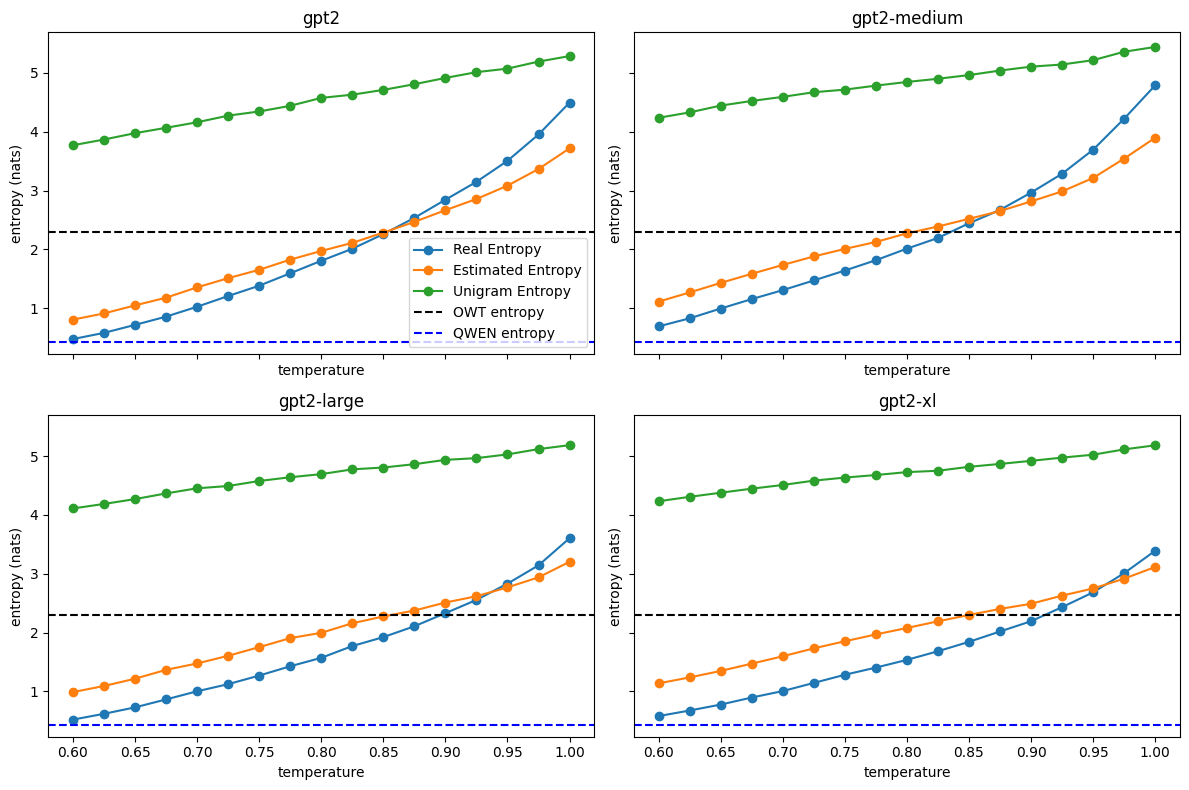

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)

axes[0, 0].plot(df_gpt2["temperature"], df_gpt2["model_entropy_real"], label="Real Entropy", marker= 'o')
axes[0, 0].plot(df_gpt2["temperature"], df_gpt2["model_entropy_est"], label="Estimated Entropy", marker= 'o')
axes[0, 0].plot(df_gpt2["temperature"], df_gpt2["unigram_entropy_est"], label="Unigram Entropy", marker= 'o')
axes[0, 0].set_title("gpt2")

axes[0, 1].plot(df_gpt2_medium["temperature"], df_gpt2_medium["model_entropy_real"], label="Real Entropy", marker= 'o')
axes[0, 1].plot(df_gpt2_medium["temperature"], df_gpt2_medium["model_entropy_est"], label="Estimated Entropy", marker= 'o')
axes[0, 1].plot(df_gpt2_medium["temperature"], df_gpt2_medium["unigram_entropy_est"], label="Unigram Entropy", marker= 'o')
axes[0, 1].set_title("gpt2-medium")

axes[1, 0].plot(df_gpt2_large["temperature"], df_gpt2_large["model_entropy_real"], label="Real Entropy", marker= 'o')
axes[1, 0].plot(df_gpt2_large["temperature"], df_gpt2_large["model_entropy_est"], label="Estimated Entropy", marker= 'o')
axes[1, 0].plot(df_gpt2_large["temperature"], df_gpt2_large["unigram_entropy_est"], label="Unigram Entropy", marker= 'o')
axes[1, 0].set_title("gpt2-large")

axes[1, 1].plot(df_gpt2_xl["temperature"], df_gpt2_xl["model_entropy_real"], label="Real Entropy", marker= 'o')
axes[1, 1].plot(df_gpt2_xl["temperature"], df_gpt2_xl["model_entropy_est"], label="Estimated Entropy", marker= 'o')
axes[1, 1].plot(df_gpt2_xl["temperature"], df_gpt2_xl["unigram_entropy_est"], label="Unigram Entropy", marker= 'o')
axes[1, 1].set_title("gpt2-xl")

for ax in axes.flatten():
    ax.axhline(y=OWT_MODEL_ENTROPY, color='black', linestyle='--', linewidth=1.5, label="OWT entropy")
    ax.axhline(y=QWEN_MODEL_ENTROPY, color='blue', linestyle='--', linewidth=1.5, label="QWEN entropy")
    ax.set_xlabel("temperature")
    ax.set_ylabel("entropy (nats)")
axes[0, 0].legend()

plt.tight_layout()
plt.show()

## Generative Frontier

Include the generative frontier and the parameter free baselines.

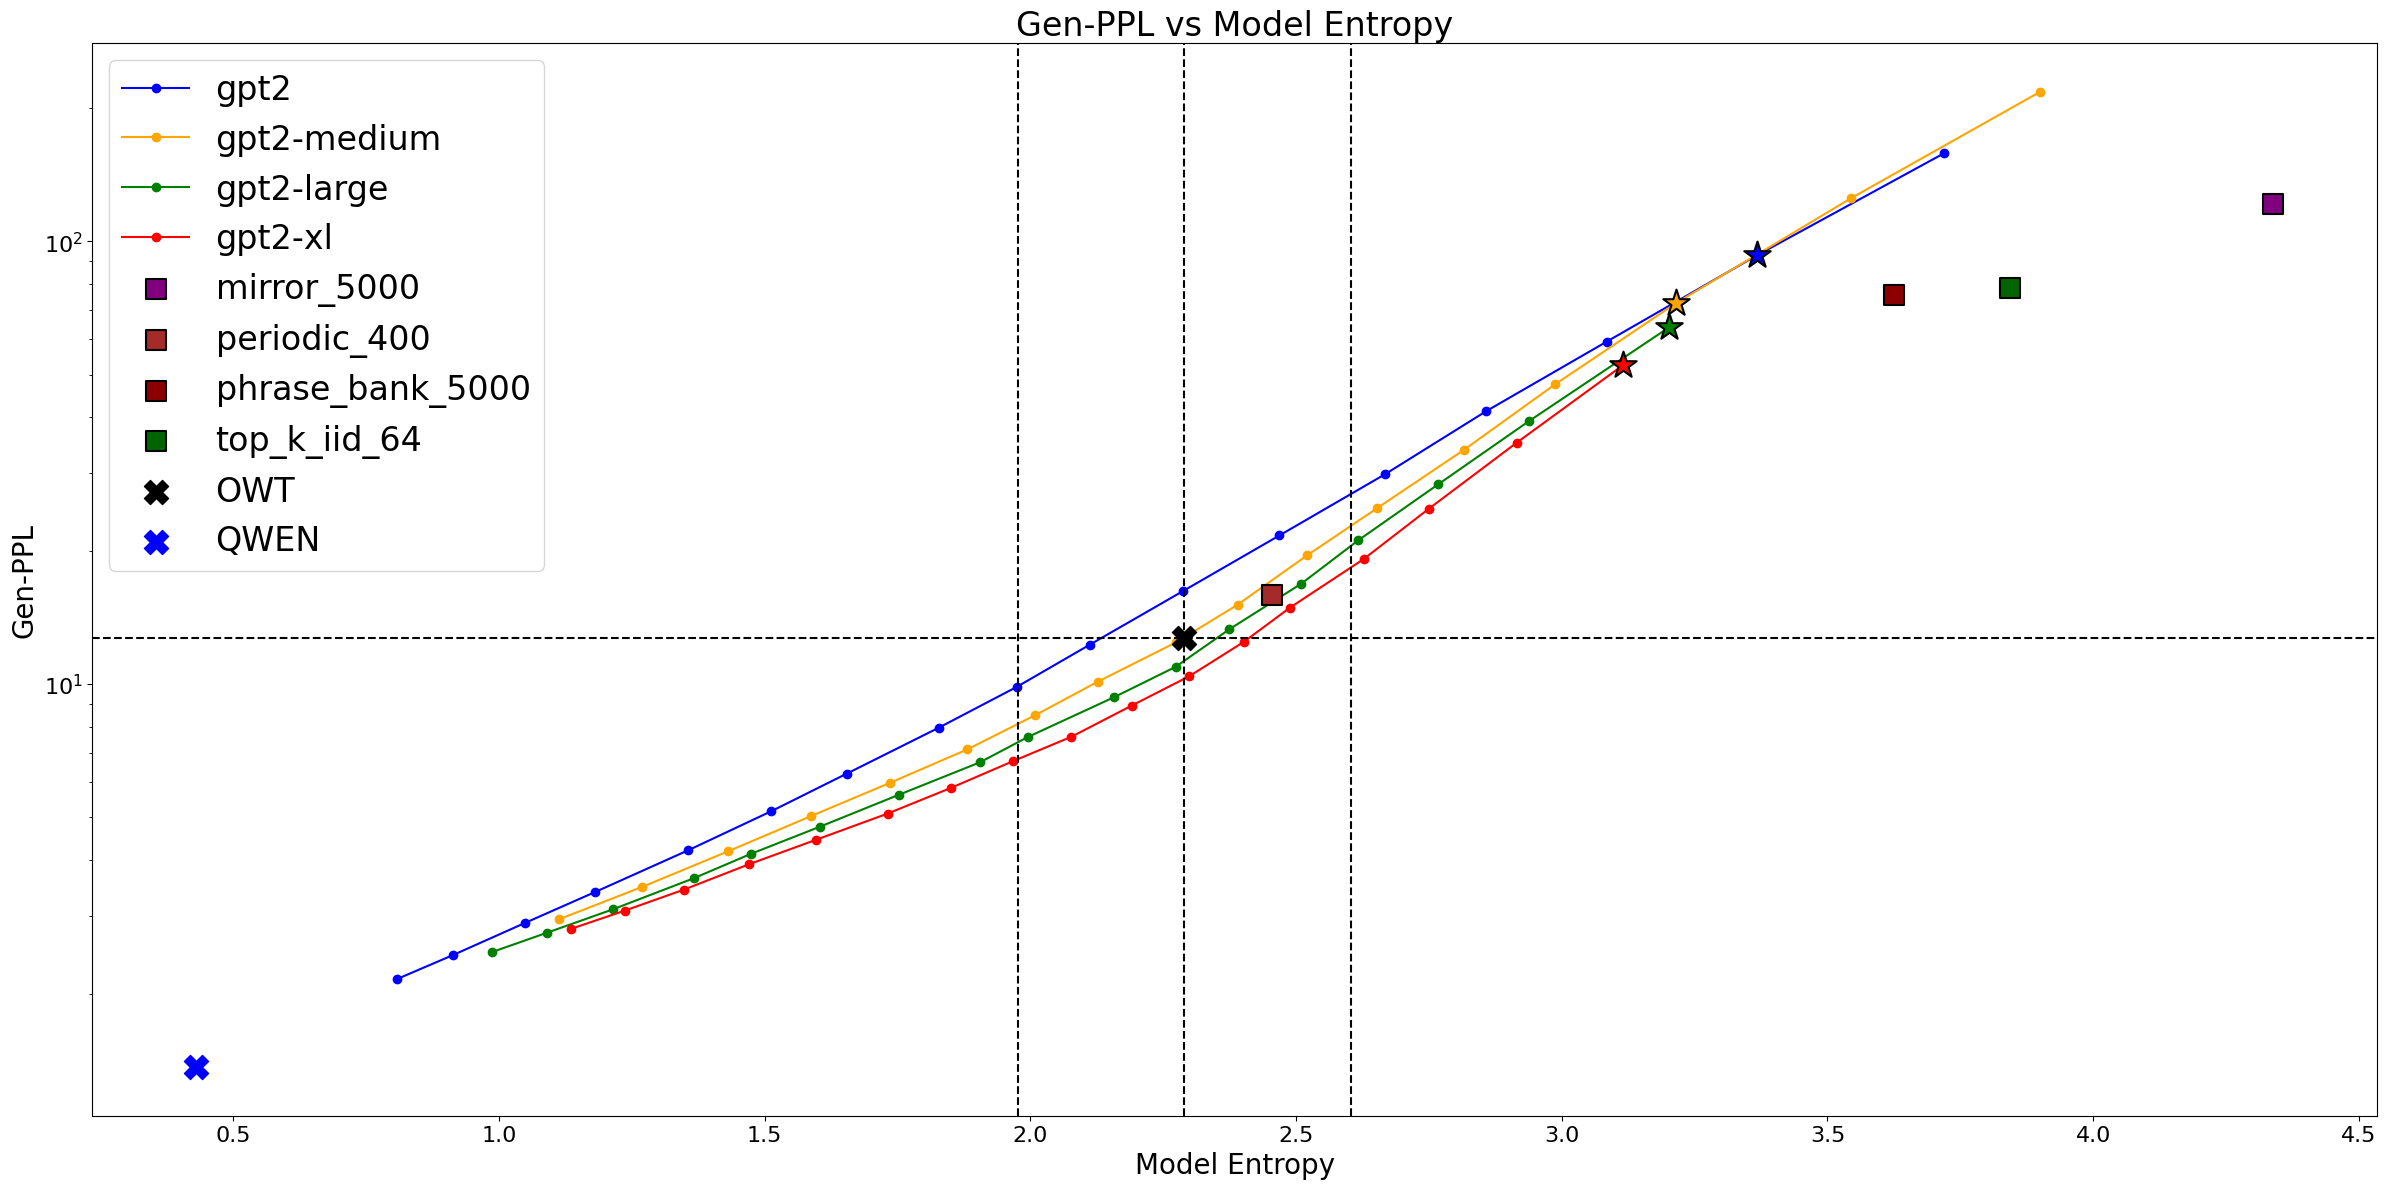

In [34]:
fig, ax = plt.subplots(figsize=(24, 12))

model_color_map = {
    "gpt2" : "blue",
    "gpt2-medium" : "orange",
    "gpt2-large" : "green",
    "gpt2-xl" : "red",
}

optimal_temp_map = {
    "gpt2": 0.975,
    "gpt2-medium": 0.95,
    "gpt2-large": 1.0,
    "gpt2-xl": 1.0,
}

param_free_color_map = {
    "mirror_5000": "purple",
    "periodic_400": "brown",
    "phrase_bank_5000": "darkred",
    "top_k_iid_64": "darkgreen",
}

ax.semilogy(df_gpt2['model_entropy_est'], df_gpt2['gen_ppl_est'], marker='o', markersize=6, label="gpt2", color=model_color_map.get("gpt2"))
ax.semilogy(df_gpt2_medium['model_entropy_est'], df_gpt2_medium['gen_ppl_est'], marker='o', markersize=6, label="gpt2-medium", color=model_color_map.get("gpt2-medium"))
ax.semilogy(df_gpt2_large['model_entropy_est'], df_gpt2_large['gen_ppl_est'], marker='o', markersize=6, label="gpt2-large", color=model_color_map.get("gpt2-large"))
ax.semilogy(df_gpt2_xl['model_entropy_est'], df_gpt2_xl['gen_ppl_est'], marker='o', markersize=6, label="gpt2-xl", color=model_color_map.get("gpt2-xl"))

optimal_gpt2 = df_gpt2[df_gpt2['temperature'] == optimal_temp_map.get("gpt2")]
optimal_gpt2_medium = df_gpt2_medium[df_gpt2_medium['temperature'] == optimal_temp_map.get("gpt2-medium")]
optimal_gpt2_large = df_gpt2_large[df_gpt2_large['temperature'] == optimal_temp_map.get("gpt2-large")]
optimal_gpt2_xl = df_gpt2_xl[df_gpt2_xl['temperature'] == optimal_temp_map.get("gpt2-xl")]

ax.scatter(optimal_gpt2['model_entropy_est'], optimal_gpt2['gen_ppl_est'], marker='*', s=400, color=model_color_map.get("gpt2"), edgecolor='black', linewidth=1.5, zorder=5)
ax.scatter(optimal_gpt2_medium['model_entropy_est'], optimal_gpt2_medium['gen_ppl_est'], marker='*', s=400, color=model_color_map.get("gpt2-medium"), edgecolor='black', linewidth=1.5, zorder=5)
ax.scatter(optimal_gpt2_large['model_entropy_est'], optimal_gpt2_large['gen_ppl_est'], marker='*', s=400, color=model_color_map.get("gpt2-large"), edgecolor='black', linewidth=1.5, zorder=5)
ax.scatter(optimal_gpt2_xl['model_entropy_est'], optimal_gpt2_xl['gen_ppl_est'], marker='*', s=400, color=model_color_map.get("gpt2-xl"), edgecolor='black', linewidth=1.5, zorder=5)

df_mirror = df_parameter_free[df_parameter_free['method'] == "mirror_5000"]
df_periodic = df_parameter_free[df_parameter_free['method'] == "periodic_400"]
df_phrase_bank = df_parameter_free[df_parameter_free['method'] == "phrase_bank_5000"]
df_top_k_iid = df_parameter_free[df_parameter_free['method'] == "top_k_iid_64"]

ax.scatter(df_mirror['model_entropy'], df_mirror['gen_ppl'], marker='s', s=200, label="mirror_5000", color=param_free_color_map.get("mirror_5000"), edgecolor='black', linewidth=1.5, zorder=5)
ax.scatter(df_periodic['model_entropy'], df_periodic['gen_ppl'], marker='s', s=200, label="periodic_400", color=param_free_color_map.get("periodic_400"), edgecolor='black', linewidth=1.5, zorder=5)
ax.scatter(df_phrase_bank['model_entropy'], df_phrase_bank['gen_ppl'], marker='s', s=200, label="phrase_bank_5000", color=param_free_color_map.get("phrase_bank_5000"), edgecolor='black', linewidth=1.5, zorder=5)
ax.scatter(df_top_k_iid['model_entropy'], df_top_k_iid['gen_ppl'], marker='s', s=200, label="top_k_iid_64", color=param_free_color_map.get("top_k_iid_64"), edgecolor='black', linewidth=1.5, zorder=5)

ax.axvline(x=OWT_MODEL_ENTROPY, color='black', linestyle='--', linewidth=1.5)
ax.axvline(x=OWT_MODEL_ENTROPY + OWT_STD, color='black', linestyle='--', linewidth=1.5)
ax.axvline(x=OWT_MODEL_ENTROPY - OWT_STD, color='black', linestyle='--', linewidth=1.5)
ax.axhline(y=OWT_GEN_PPL, color='black', linestyle='--', linewidth=1.5)
ax.scatter([OWT_MODEL_ENTROPY], [OWT_GEN_PPL], marker='X', s=300, color='black', zorder=5, label='OWT')
ax.scatter([QWEN_MODEL_ENTROPY], [QWEN_GEN_PPL], marker='X', s=300, color='blue', zorder=5, label='QWEN')

ax.set_xlabel('Model Entropy', fontsize=20)
ax.set_ylabel('Gen-PPL', fontsize=20)
ax.tick_params(axis='both', labelsize=16)
ax.set_title("Gen-PPL vs Model Entropy", fontsize=24)
ax.legend(fontsize=24)
fig.tight_layout()
fig.show()

## KL vs Temperature

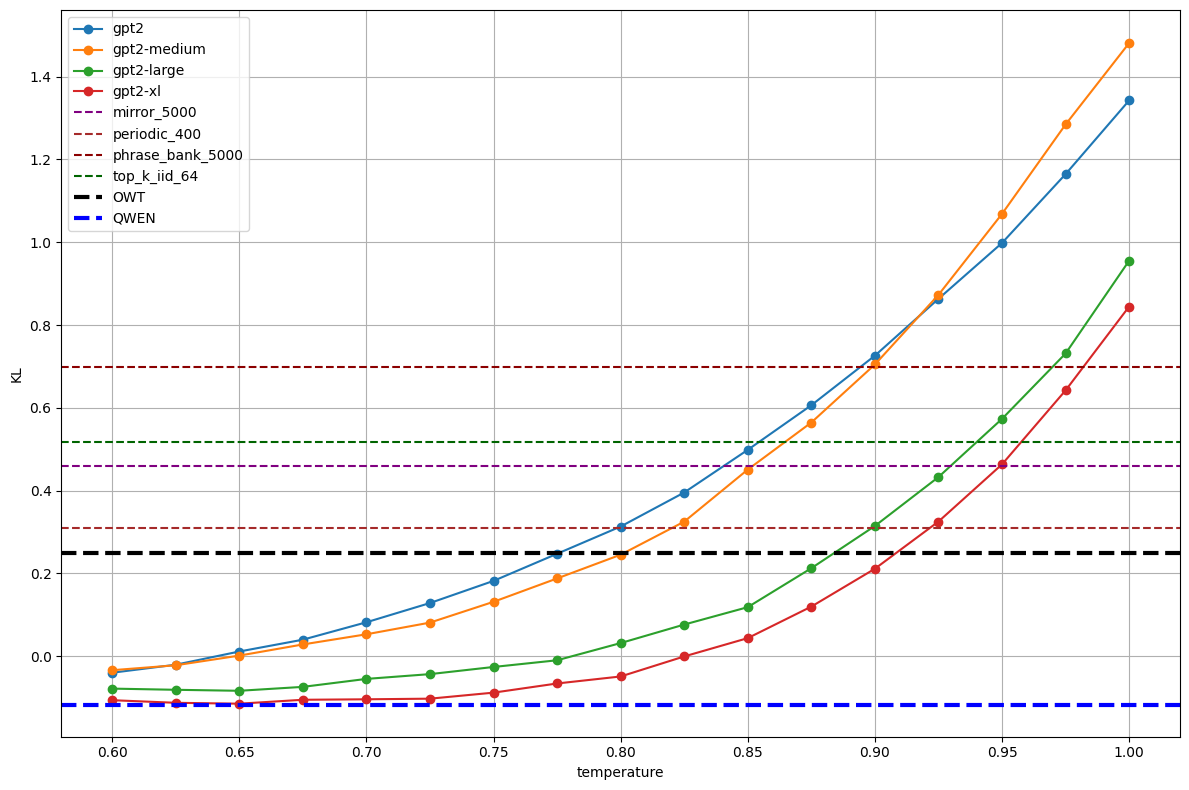

In [35]:
plt.figure(figsize=(12, 8))

plt.plot(df_gpt2["temperature"], df_gpt2["kl_est"], label="gpt2", marker= 'o')
plt.plot(df_gpt2_medium["temperature"], df_gpt2_medium["kl_est"], label="gpt2-medium", marker= 'o')
plt.plot(df_gpt2_large["temperature"], df_gpt2_large["kl_est"], label="gpt2-large", marker= 'o')
plt.plot(df_gpt2_xl["temperature"], df_gpt2_xl["kl_est"], label="gpt2-xl", marker= 'o')

# Naive samplers
kl_param_free = np.log(df_parameter_free["gen_ppl"]) - df_parameter_free["model_entropy"]
for method, kl in zip(df_parameter_free["method"], kl_param_free):
    plt.axhline(y=kl, linestyle='--', linewidth=1.5, color=param_free_color_map.get(method), label=method)

#Add Qwen and OWT
plt.axhline(y=KL_OWT, color='black', linestyle='--', linewidth=3, label="OWT")
plt.axhline(y=KL_QWEN, color='blue', linestyle='--', linewidth=3, label="QWEN")

plt.xlabel("temperature")
plt.ylabel("KL")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

## KL vs Temp regulated by alpha

$$
{\mathrm{KL}}(q_{\text{gen}} \,\|\, p_{\text{ref}}) = H(q_{\text{gen}}, p_{\text{ref}}) - \alpha H(q_{\text{gen}})
$$

Min index: 8, Min Temp = 0.8


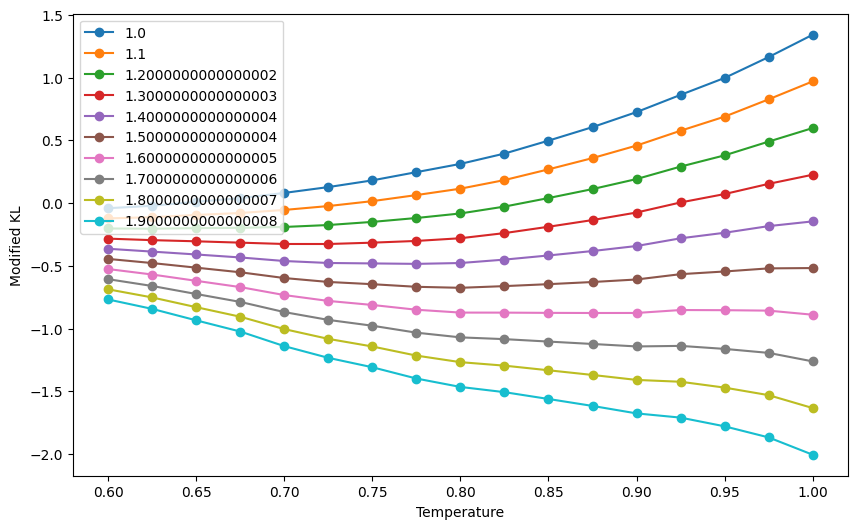

In [36]:
alphas = np.arange(1, 2, 0.1)

fig = plt.figure(figsize=(10, 6))
for alpha in alphas:
    modified_KL = np.log(df_gpt2["gen_ppl_est"]) - alpha * df_gpt2["model_entropy_est"]
    plt.plot(df_gpt2["temperature"], modified_KL, label=f"{alpha}", marker='o')

plt.xlabel("Temperature")
plt.ylabel("Modified KL")
plt.legend()


modified_KL_145 = np.log(df_gpt2["gen_ppl_est"]) - 1.45 * df_gpt2["model_entropy_est"]

min_index = np.argmin(modified_KL_145)
min_temp = df_gpt2["temperature"].to_numpy()[min_index]

print(f"Min index: {min_index}, Min Temp = {min_temp}")


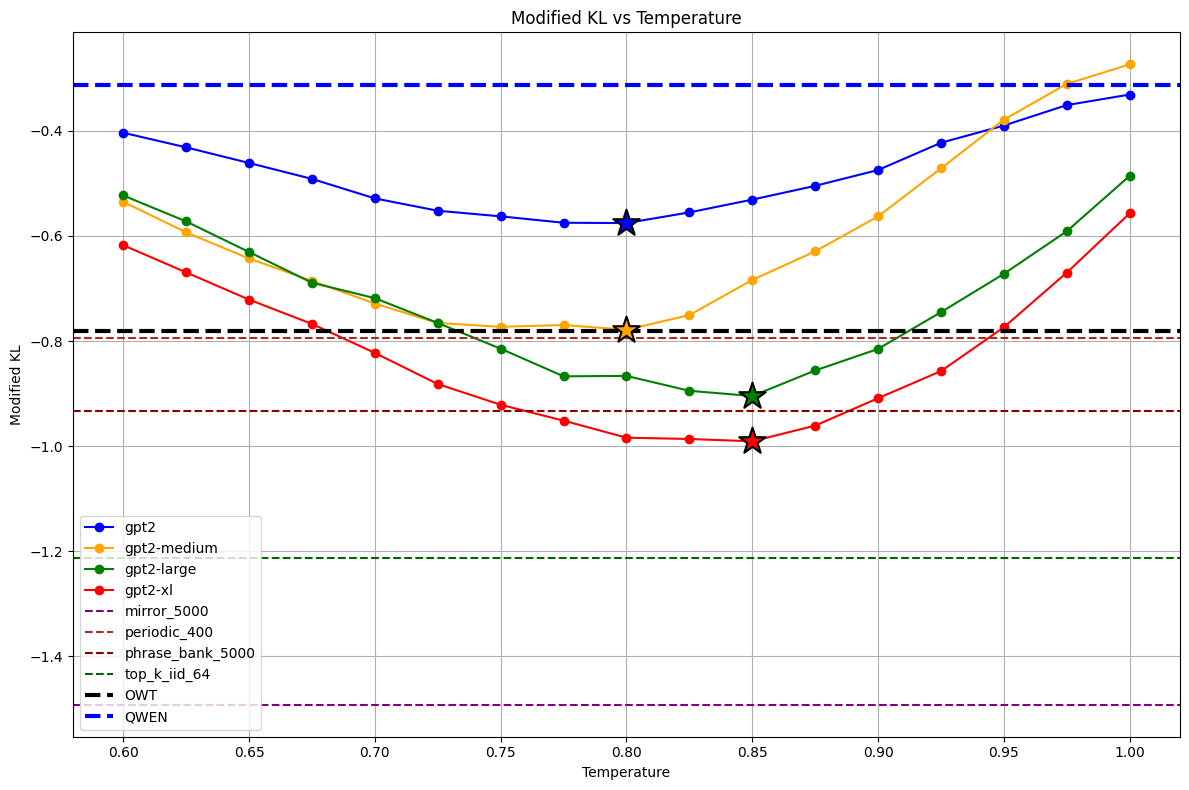

In [37]:
ALPHA = 1.45

model_dfs = {
    "gpt2": df_gpt2,
    "gpt2-medium": df_gpt2_medium,
    "gpt2-large": df_gpt2_large,
    "gpt2-xl": df_gpt2_xl,
}

plt.figure(figsize=(12, 8))

for name, df in model_dfs.items():
    modified_KL = np.log(df["gen_ppl_est"]) - ALPHA * df["model_entropy_est"]
    temperature = df["temperature"].to_numpy()
    color = model_color_map.get(name)

    plt.plot(temperature, modified_KL, label=name, marker='o', color=color)

    min_index = np.argmin(modified_KL)
    min_temp = temperature[min_index]
    plt.scatter([min_temp], [modified_KL[min_index]], marker='*', s=400,
                color=color, edgecolor='black', linewidth=1.5, zorder=5)

# Naive samplers
modified_KL_param_free = np.log(df_parameter_free["gen_ppl"]) - ALPHA * df_parameter_free["model_entropy"]
for method, modified_kl in zip(df_parameter_free["method"], modified_KL_param_free):
    plt.axhline(y=modified_kl, linestyle='--', linewidth=1.5, color=param_free_color_map.get(method), label=method)

#Qwen and OWT
QWEN_MOD_KL = np.log(QWEN_GEN_PPL) - ALPHA * QWEN_MODEL_ENTROPY
OWT_MOD_KL = np.log(OWT_GEN_PPL) - ALPHA * OWT_MODEL_ENTROPY
plt.axhline(y=OWT_MOD_KL, color='black', linestyle='--', linewidth=3, label="OWT")
plt.axhline(y=QWEN_MOD_KL, color='blue', linestyle='--', linewidth=3, label="QWEN")

plt.xlabel("Temperature")
plt.ylabel(f"Modified KL")
plt.title(f"Modified KL vs Temperature")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

## KL actual vs temperature

KL computed using the results from the model's actual entropy.

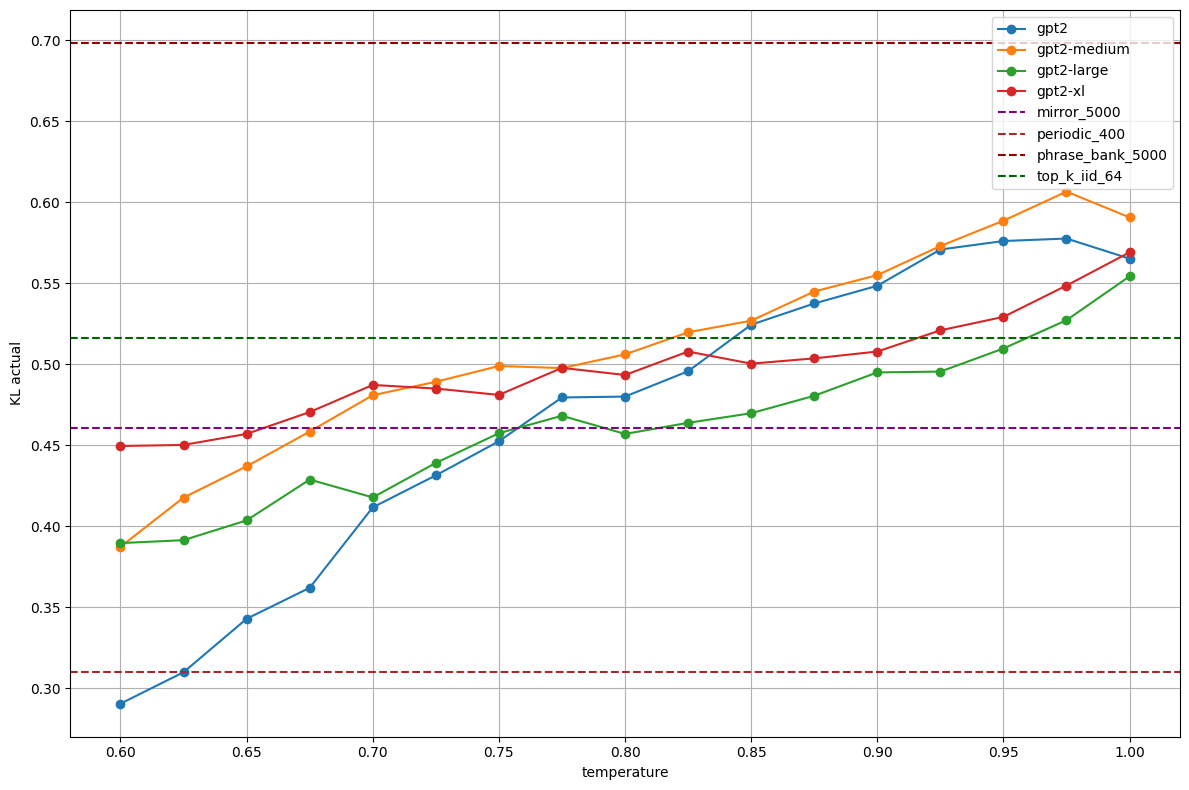

In [38]:
plt.figure(figsize=(12, 8))

plt.plot(df_gpt2["temperature"], df_gpt2["kl_actual"], label="gpt2", marker= 'o')
plt.plot(df_gpt2_medium["temperature"], df_gpt2_medium["kl_actual"], label="gpt2-medium", marker= 'o')
plt.plot(df_gpt2_large["temperature"], df_gpt2_large["kl_actual"], label="gpt2-large", marker= 'o')
plt.plot(df_gpt2_xl["temperature"], df_gpt2_xl["kl_actual"], label="gpt2-xl", marker= 'o')

# Naive samplers have no temperature, so they enter as horizontal references
kl_param_free = np.log(df_parameter_free["gen_ppl"]) - df_parameter_free["model_entropy"]
for method, kl in zip(df_parameter_free["method"], kl_param_free):
    plt.axhline(y=kl, linestyle='--', linewidth=1.5, color=param_free_color_map.get(method), label=method)

plt.xlabel("temperature")
plt.ylabel("KL actual")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

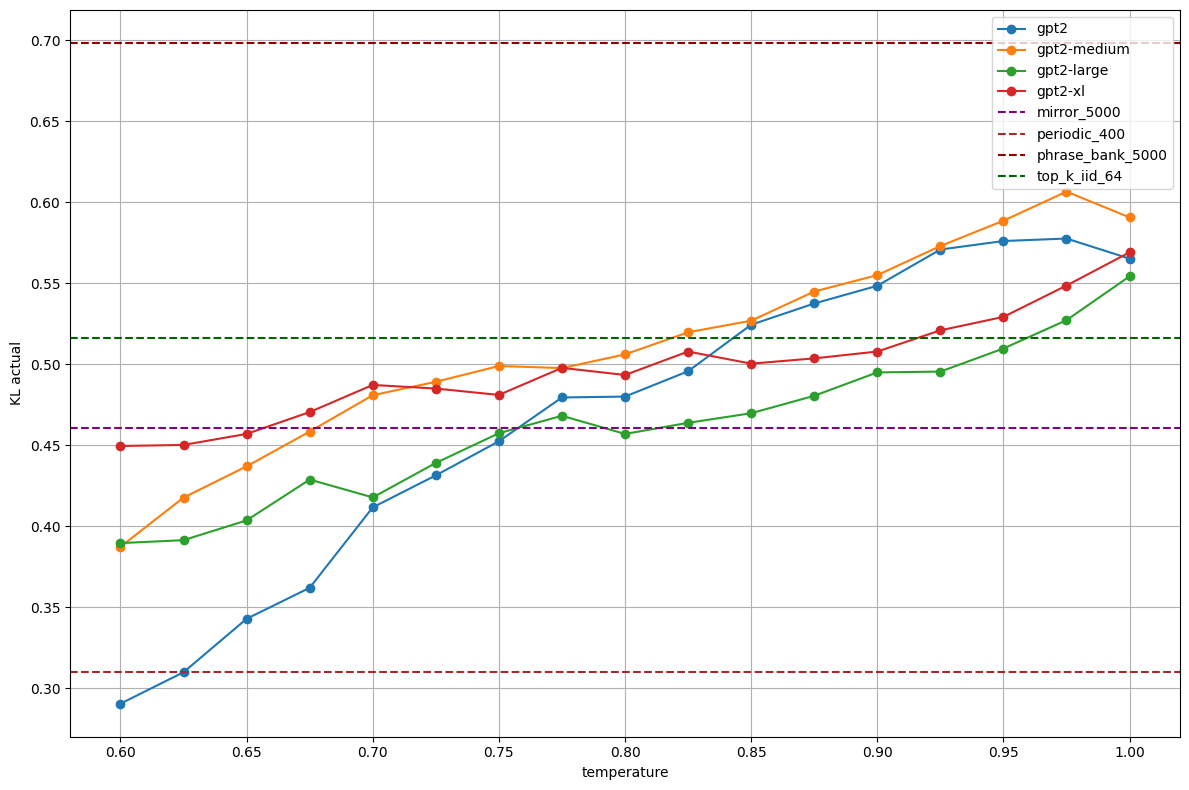

In [39]:
plt.figure(figsize=(12, 8))

plt.plot(df_gpt2["temperature"], df_gpt2["kl_actual"], label="gpt2", marker= 'o')
plt.plot(df_gpt2_medium["temperature"], df_gpt2_medium["kl_actual"], label="gpt2-medium", marker= 'o')
plt.plot(df_gpt2_large["temperature"], df_gpt2_large["kl_actual"], label="gpt2-large", marker= 'o')
plt.plot(df_gpt2_xl["temperature"], df_gpt2_xl["kl_actual"], label="gpt2-xl", marker= 'o')

# Naive samplers have no temperature, so they enter as horizontal references
kl_param_free = np.log(df_parameter_free["gen_ppl"]) - df_parameter_free["model_entropy"]
for method, kl in zip(df_parameter_free["method"], kl_param_free):
    plt.axhline(y=kl, linestyle='--', linewidth=1.5, color=param_free_color_map.get(method), label=method)

plt.xlabel("temperature")
plt.ylabel("KL actual")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

## Test Repetition Penalty for genPPL

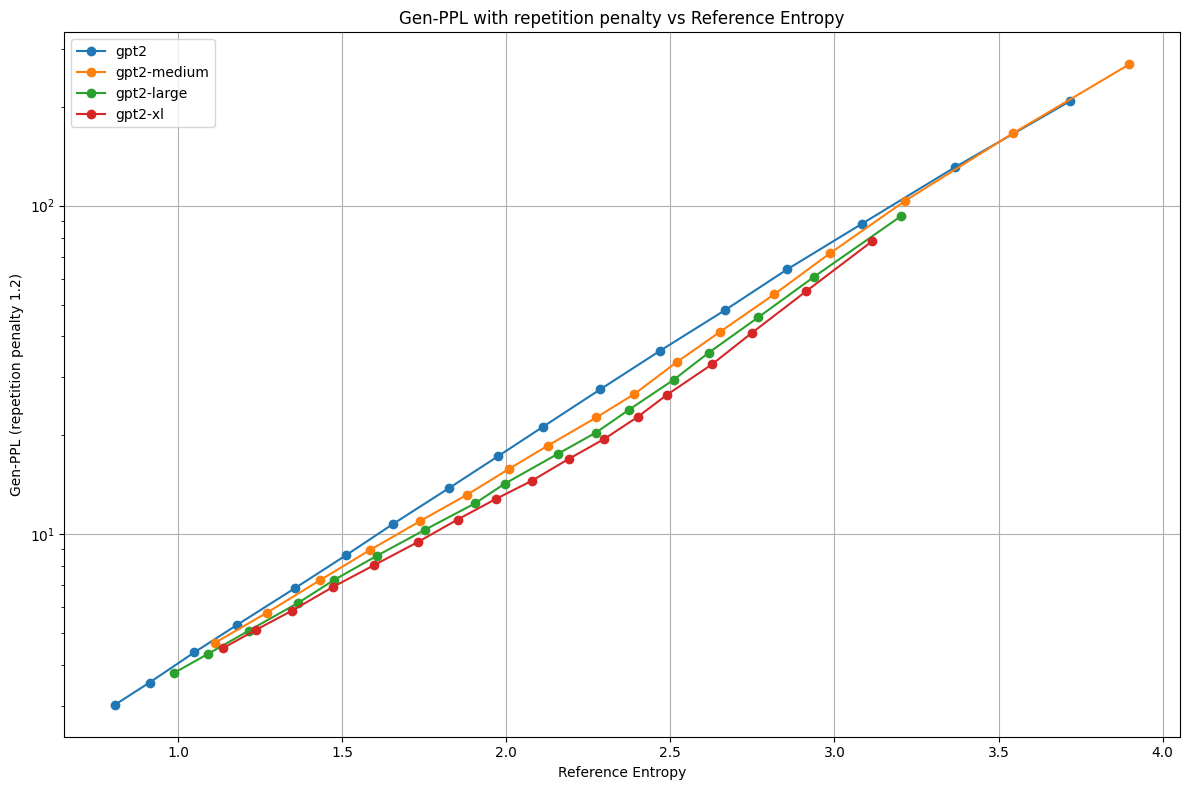

In [40]:
REP_PEN_PATH = "outputs/qwen4Beval_topp1_rep_pen_1.2/all_metrics_analysis/divergence_metrics.csv"
NO_REP_PEN_PATH = "outputs/qwen4Beval_2/all_metrics_analysis/divergence_metrics.csv"

df_rep_penalty = pd.read_csv(REP_PEN_PATH)
df_no_rep_penalty = pd.read_csv(NO_REP_PEN_PATH)

# gen_ppl from the rep_penalty=1.2 run, reference entropy from the normal run
df_penalty = df_rep_penalty[["method", "temperature", "gen_ppl"]].merge(
    df_no_rep_penalty[["method", "temperature", "model_entropy"]],
    on=["method", "temperature"],
    how="inner",
)
df_penalty_gpt2 = df_penalty[df_penalty["method"] == "openai-community_gpt2"].sort_values("model_entropy")
df_penalty_gpt2_medium = df_penalty[df_penalty["method"] == "openai-community_gpt2-medium"].sort_values("model_entropy")
df_penalty_gpt2_large = df_penalty[df_penalty["method"] == "openai-community_gpt2-large"].sort_values("model_entropy")
df_penalty_gpt2_xl = df_penalty[df_penalty["method"] == "openai-community_gpt2-xl"].sort_values("model_entropy")

plt.figure(figsize=(12, 8))

plt.semilogy(df_penalty_gpt2["model_entropy"], df_penalty_gpt2["gen_ppl"], label="gpt2", marker= 'o')
plt.semilogy(df_penalty_gpt2_medium["model_entropy"], df_penalty_gpt2_medium["gen_ppl"], label="gpt2-medium", marker= 'o')
plt.semilogy(df_penalty_gpt2_large["model_entropy"], df_penalty_gpt2_large["gen_ppl"], label="gpt2-large", marker= 'o')
plt.semilogy(df_penalty_gpt2_xl["model_entropy"], df_penalty_gpt2_xl["gen_ppl"], label="gpt2-xl", marker= 'o')

plt.xlabel("Reference Entropy")
plt.ylabel("Gen-PPL (repetition penalty 1.2)")
plt.title("Gen-PPL with repetition penalty vs Reference Entropy")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

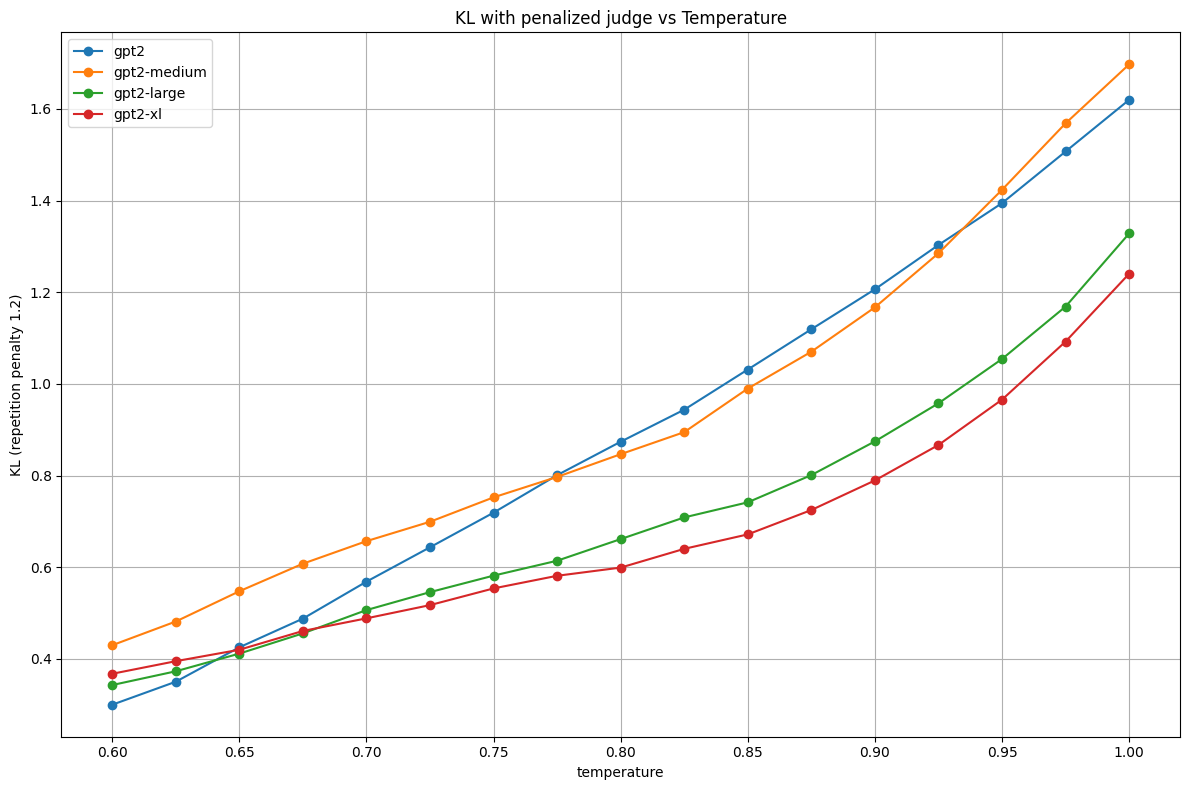

In [41]:
# KL with the penalized gen_ppl and the unpenalized reference entropy
df_penalty["kl_pen"] = np.log(df_penalty["gen_ppl"]) - df_penalty["model_entropy"]
df_penalty_gpt2 = df_penalty[df_penalty["method"] == "openai-community_gpt2"].sort_values("temperature")
df_penalty_gpt2_medium = df_penalty[df_penalty["method"] == "openai-community_gpt2-medium"].sort_values("temperature")
df_penalty_gpt2_large = df_penalty[df_penalty["method"] == "openai-community_gpt2-large"].sort_values("temperature")
df_penalty_gpt2_xl = df_penalty[df_penalty["method"] == "openai-community_gpt2-xl"].sort_values("temperature")

#Plot
plt.figure(figsize=(12, 8))
plt.plot(df_penalty_gpt2["temperature"], df_penalty_gpt2["kl_pen"], label="gpt2", marker= 'o')
plt.plot(df_penalty_gpt2_medium["temperature"], df_penalty_gpt2_medium["kl_pen"], label="gpt2-medium", marker= 'o')
plt.plot(df_penalty_gpt2_large["temperature"], df_penalty_gpt2_large["kl_pen"], label="gpt2-large", marker= 'o')
plt.plot(df_penalty_gpt2_xl["temperature"], df_penalty_gpt2_xl["kl_pen"], label="gpt2-xl", marker= 'o')
plt.xlabel("temperature")
plt.ylabel("KL (repetition penalty 1.2)")
plt.title("KL with penalized judge vs Temperature")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

## OWT Entropy Histogram

torch.Size([100000, 3])


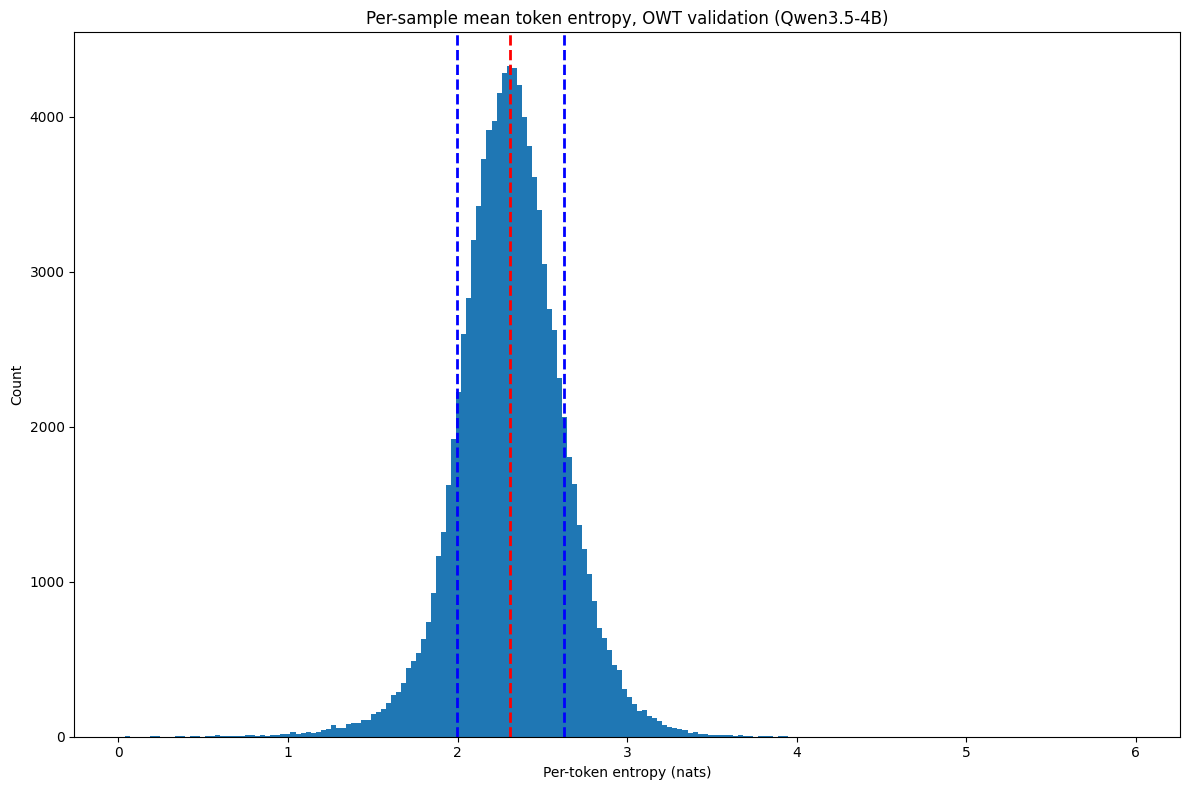

Mean per-token entropy: 2.3121 nats
Std per-token entropy: 0.3139 nats


In [42]:
import torch

owt = torch.load("outputs/openwebtext_analysis/model_entropy/Qwen_Qwen3.5_4B/data/per_sample_metrics.pt")
print(owt.shape)
normalized_entropy = owt[:, 1] / owt[:, 2]
mean = normalized_entropy.mean().item()
std = normalized_entropy.std().item()
plt.figure(figsize=(12, 8))
plt.hist(normalized_entropy.numpy(), bins=200)

plt.axvline(x=mean, color='red', linestyle='--', linewidth=2, label=f"Mean: {mean:.4f}")
plt.axvline(x=mean - std, color='blue', linestyle='--', linewidth=2, label=f"Std: {std:.4f}")
plt.axvline(x=mean + std, color='blue', linestyle='--', linewidth=2, label=f"Std: {std:.4f}")
plt.xlabel("Per-token entropy (nats)")
plt.ylabel("Count")
plt.title("Per-sample mean token entropy, OWT validation (Qwen3.5-4B)")
plt.tight_layout()
plt.show()

print(f"Mean per-token entropy: {mean:.4f} nats")
print(f"Std per-token entropy: {std:.4f} nats")

In [43]:
owt_entropy_tensor[1]

tensor([771.4990, 714.7775, 312.0000], dtype=torch.float64)